<a href="https://colab.research.google.com/github/TejasKayarkar03/Pattern-Recognition-Lab/blob/main/PR_CM23045_Pr_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics.pairwise import manhattan_distances
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
uploaded = files.upload()

Saving Wholesale customers data.csv to Wholesale customers data.csv


In [ ]:
df = pd.read_csv("Wholesale customers data.csv")

df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [ ]:
print(df.shape)
print(df.info())
print(df.describe())

(440, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None
          Channel      Region          Fresh          Milk       Grocery  \
count  440.000000  440.000000     440.000000    440.000000    440.000000   
mean     1.322727    2.543182   12000.297727   5796.265909   7951.277273   
std      0.468052    0.774272   12647.328865   7380.377175   9503.162829   
min      1.000000    1.000000       3.000000     55.000000      3.000000   
25%      1.00

In [ ]:
X = df[['Fresh',
        'Milk',
        'Grocery',
        'Frozen',
        'Detergents_Paper',
        'Delicassen']]

X.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
euclidean = euclidean_distances(X_scaled)

print("Euclidean Distance Matrix (First 5 Customers):")
print(euclidean[:5, :5])

Euclidean Distance Matrix (First 5 Customers):
[[0.         0.62085789 2.41519574 1.81797539 1.85368169]
 [0.62085789 0.         2.1728031  1.78402686 1.92309716]
 [2.41519574 2.1728031  0.         2.68326584 1.73016663]
 [1.81797539 1.78402686 2.68326584 0.         1.66185355]
 [1.85368169 1.92309716 1.73016663 1.66185355 0.        ]]


In [ ]:
manhattan = manhattan_distances(X_scaled)

print("Manhattan Distance Matrix (First 5 Customers):")
print(manhattan[:5, :5])

Manhattan Distance Matrix (First 5 Customers):
[[0.         1.28125496 3.56621373 3.43790898 3.71877284]
 [1.28125496 0.         2.72368947 3.76972177 4.05058563]
 [3.56621373 2.72368947 0.         5.55089947 3.41989166]
 [3.43790898 3.76972177 5.55089947 0.         3.61126396]
 [3.71877284 4.05058563 3.41989166 3.61126396 0.        ]]


In [ ]:
cosine = cosine_similarity(X_scaled)

print("Cosine Similarity Matrix (First 5 Customers):")
print(cosine[:5, :5])

Cosine Similarity Matrix (First 5 Customers):
[[ 1.          0.67957836  0.06355325 -0.77123244 -0.12619249]
 [ 0.67957836  1.          0.36523413 -0.7810608  -0.2711514 ]
 [ 0.06355325  0.36523413  1.         -0.0908649   0.67038538]
 [-0.77123244 -0.7810608  -0.0908649   1.          0.28235514]
 [-0.12619249 -0.2711514   0.67038538  0.28235514  1.        ]]


In [ ]:
def edit_distance(s1, s2):

    m = len(s1)
    n = len(s2)

    dp = [[0]*(n+1) for _ in range(m+1)]

    for i in range(m+1):
        dp[i][0] = i

    for j in range(n+1):
        dp[0][j] = j

    for i in range(1, m+1):
        for j in range(1, n+1):

            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1]

            else:
                dp[i][j] = 1 + min(
                    dp[i-1][j],
                    dp[i][j-1],
                    dp[i-1][j-1]
                )

    return dp[m][n]

In [ ]:
customer1 = "Customer1"
customer2 = "Customer2"

distance = edit_distance(customer1, customer2)

print("Edit Distance:", distance)

Edit Distance: 1


In [ ]:
print("Euclidean Distance :", euclidean[0][1])

print("Manhattan Distance :", manhattan[0][1])

print("Cosine Similarity :", cosine[0][1])

Euclidean Distance : 0.6208578911211604
Manhattan Distance : 1.281254955895562
Cosine Similarity : 0.6795783596851255


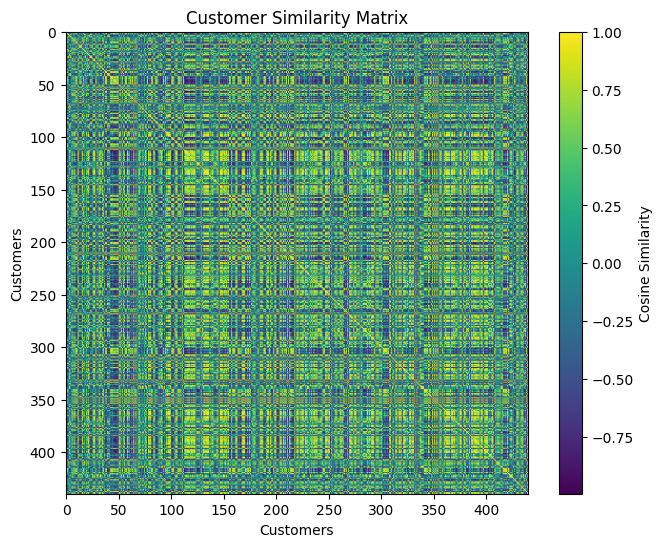

In [ ]:
plt.figure(figsize=(8,6))

plt.imshow(cosine, cmap="viridis")

plt.colorbar(label="Cosine Similarity")

plt.title("Customer Similarity Matrix")

plt.xlabel("Customers")

plt.ylabel("Customers")

plt.show()

In [ ]:
similarities = cosine[0]

similarities[0] = -1

most_similar = np.argmax(similarities)

print("Customer 1 is most similar to Customer", most_similar)

print("Cosine Similarity Score:", similarities[most_similar])

Customer 1 is most similar to Customer 5
Cosine Similarity Score: 0.8213684573218397
